# BITUN

In [63]:
import pandas as pd
import numpy as np

df = pd.read_csv('DASS.csv')

<h1> Missing data imputation </h1>

<h2> 1.1 Complete Case Analysis </h2>

In [64]:
df_cca = df.dropna()

<h2> 1.2 Mean/Median/Mode Imputation </h2>

In [65]:

df['age_median'] = df['age'].fillna(df['age'].median())
df['gender_mode'] = df['gender'].fillna(df['gender'].mode()[0])

<h2> 1.3 Random Sample Imputation </h2>

In [66]:

def random_sample_impute(df, variable):
    df[variable + '_random'] = df[variable]
    random_sample = df[variable].dropna().sample(df[variable].isnull().sum(), random_state=0)
    random_sample.index = df[df[variable].isnull()].index
    df.loc[df[variable].isnull(), variable + '_random'] = random_sample

<h2> 1.4 Replacement by Arbitrary Value </h2>

In [67]:
df['age_arbitrary'] = df['age'].fillna(99)

<h2> 1.5 End of Distribution Imputation </h2>

In [68]:
extreme_value = df['age'].mean() + 3 * df['age'].std()
df['age_end_dist'] = df['age'].fillna(extreme_value)

<h2> 1.6 Missing Value Indicator  </h2>

In [69]:
df['age_nan_tag'] = np.where(df['age'].isnull(), 1, 0)

<h1> Categorical encoding </h1>

<h3> 2.1 One-Hot Encoding (OHE)</h3>

In [70]:
df_ohe = pd.get_dummies(df['country'], drop_first=True)


<h3> 2.2 Ordinal Encoding (Mapping levels) </h3>

In [71]:
education_map = {'Primary': 1, 'Secondary': 2, 'University': 3}
df['education_ordinal'] = df['education'].map(education_map)

<h3> 2.3 Count and Frequency Encoding </h3>

In [72]:
freq_map = df['country'].value_counts().to_dict()
df['country_freq'] = df['country'].map(freq_map)

<h3> 2.4 Target/Mean Encoding </h3>

In [73]:
# DASS-42 Question Items
depression_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']
anxiety_items = ['Q2A', 'Q4A', 'Q7A', 'Q9A', 'Q15A', 'Q19A', 'Q20A', 'Q23A', 'Q25A', 'Q28A', 'Q30A', 'Q36A', 'Q40A', 'Q41A']
stress_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 'Q22A', 'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']

# Calculate Scores (subtract 14 because each item is scored 0-3 instead of 1-4)
df['depression_score'] = df[depression_items].sum(axis=1) - 14
df['anxiety_score'] = df[anxiety_items].sum(axis=1) - 14
df['stress_score'] = df[stress_items].sum(axis=1) - 14

# Create Level Classifications
def classify_dass_level(score):
    if score <= 9:
        return 'Normal'
    elif score <= 13:
        return 'Mild'
    elif score <= 20:
        return 'Moderate'
    elif score <= 27:
        return 'Severe'
    else:
        return 'Extremely Severe'

df['depression_level'] = df['depression_score'].apply(classify_dass_level)
df['anxiety_level'] = df['anxiety_score'].apply(classify_dass_level)
df['stress_level'] = df['stress_score'].apply(classify_dass_level)

# Display score distributions
print("Depression Score Statistics:")
print(df['depression_score'].describe())
print("\nAnxiety Score Statistics:")
print(df['anxiety_score'].describe())
print("\nStress Score Statistics:")
print(df['stress_score'].describe())

# Target encoding for country
target_map = df.groupby(['country'])['stress_score'].mean().to_dict()
df['country_target_encoded'] = df['country'].map(target_map)

print(df[['country', 'country_target_encoded']].head())

Depression Score Statistics:
count    39775.000000
mean        21.060088
std         12.321566
min          0.000000
25%         11.000000
50%         21.000000
75%         32.000000
max         42.000000
Name: depression_score, dtype: float64

Anxiety Score Statistics:
count    39775.000000
mean        16.054758
std         10.249169
min          0.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         42.000000
Name: anxiety_score, dtype: float64

Stress Score Statistics:
count    39775.000000
mean        21.153891
std         10.523291
min          0.000000
25%         13.000000
50%         21.000000
75%         29.000000
max         42.000000
Name: stress_score, dtype: float64
  country  country_target_encoded
0      IN               20.343049
1      US               22.071890
2      PL               22.843023
3      US               22.071890
4      MY               20.845545


<h3> 3.1 Logarithmic Transformation </h3>

In [74]:
import scipy.stats as stats

df['age_log'] = np.log(df['age'] + 1)

<h3> 3.2 Reciprocal Transformation </h3>

In [75]:
df['age_reciprocal'] = 1 / (df['age'] + 1)

<h3> 3.3 Square-root Transformation </h3>

In [76]:
df['age_sqr'] = df['age']**(1/2)

<h3> 3.4 Exponential Transformation </h3>

In [77]:
df['age_exp'] = df['age']**(1.5)

</h3> 3.5 Box-Cox Transformation </h3>

In [78]:
df['age_boxcox'], param = stats.boxcox(df['age'] + 1)

<h1> Discretization </h1>

<h3> 4.1 Equal width discretization with pandas cut function </h3>

In [79]:
df['age_width'] = pd.cut(df['age'], bins=5)

<h3> 4.2 Equal frequency discretization with pandas qcut function </h3>

In [80]:
df['age_freq'] = pd.qcut(df['age'], q=5)

<h3> 4.3 Domain knowledge discretization </h3>

In [81]:
bins = [0, 18, 35, 60, 100]
labels = ['Minor', 'Young Adult', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

<h1> Outlier Engineering </h1>

In [82]:
IQR = df['age'].quantile(0.75) - df['age'].quantile(0.25)
lower_bridge = df['age'].quantile(0.25) - (IQR * 1.5)
upper_bridge = df['age'].quantile(0.75) + (IQR * 1.5)

<h3> 5.1 Outlier removal </h3>

In [83]:
df_no_outliers = df[(df['age'] >= lower_bridge) & (df['age'] <= upper_bridge)]


<h3> 5.2 Treating outliers as missing values </h3>

In [84]:
df.loc[df['age'] > upper_bridge, 'age'] = np.nan

<h3> 5.3 Discretization </h3>

<h3> 5.4 Top/bottom/zero coding </h3>

In [85]:
df.loc[df['age'] > upper_bridge, 'age'] = upper_bridge
df.loc[df['age'] < lower_bridge, 'age'] = lower_bridge

# EDA 

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

<h3> Univariate </h3>

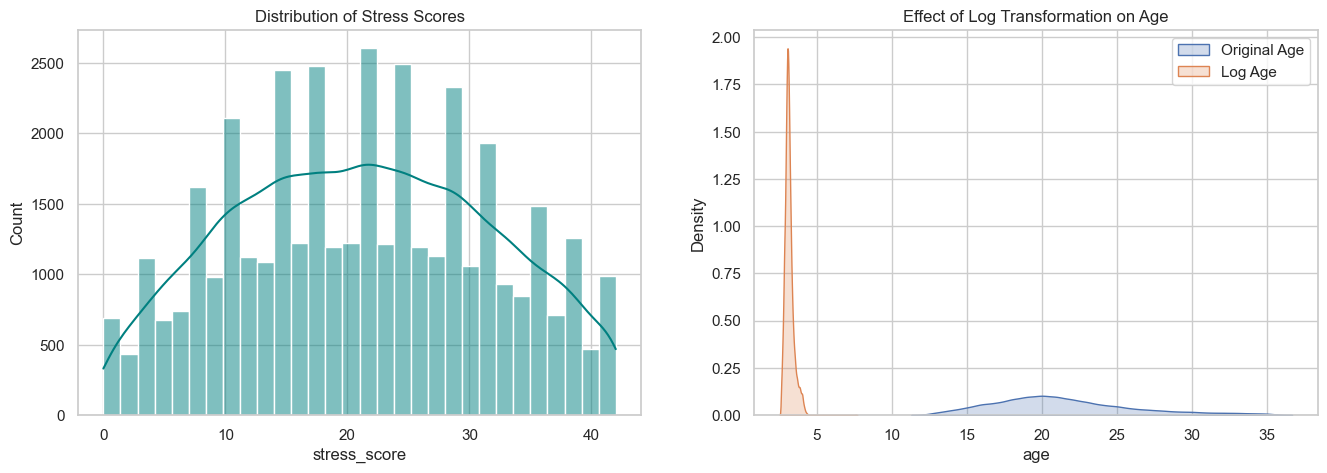

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['stress_score'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Stress Scores')

sns.kdeplot(df['age'], label='Original Age', ax=axes[1], fill=True)
sns.kdeplot(df['age_log'], label='Log Age', ax=axes[1], fill=True)
axes[1].set_title('Effect of Log Transformation on Age')
plt.legend()
plt.show()

<h3> Categorical </h3>

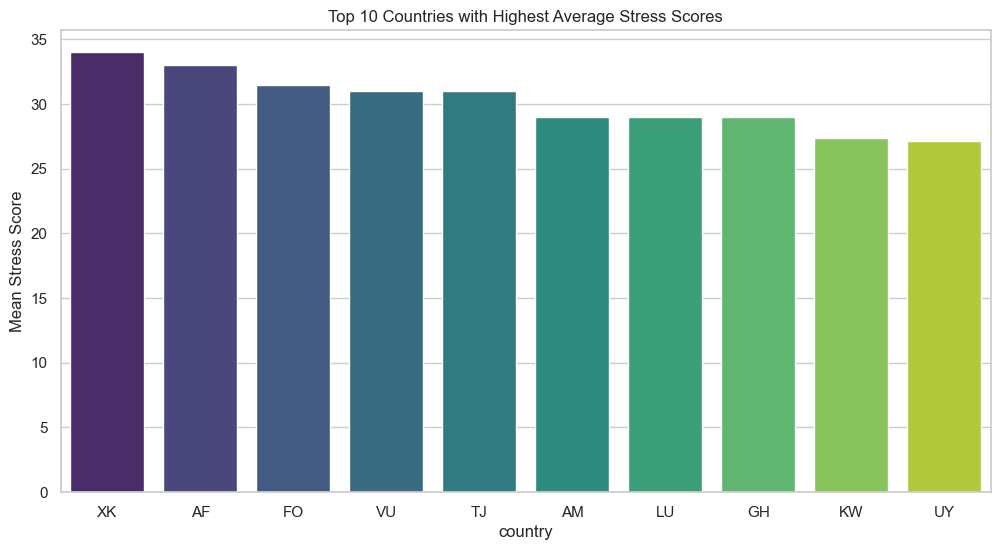

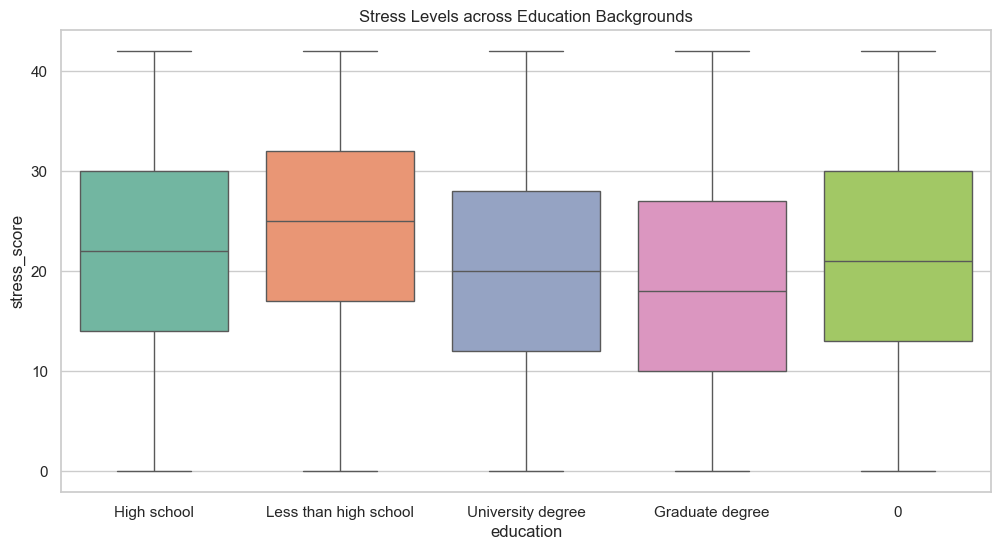

In [88]:
top_countries = df.groupby('country')['stress_score'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.index, y=top_countries.values, palette='viridis')
plt.title('Top 10 Countries with Highest Average Stress Scores')
plt.ylabel('Mean Stress Score')
plt.show()

sns.boxplot(x='education', y='stress_score', data=df, palette='Set2')
plt.title('Stress Levels across Education Backgrounds')
plt.show()

<h3> Correlational </h3>

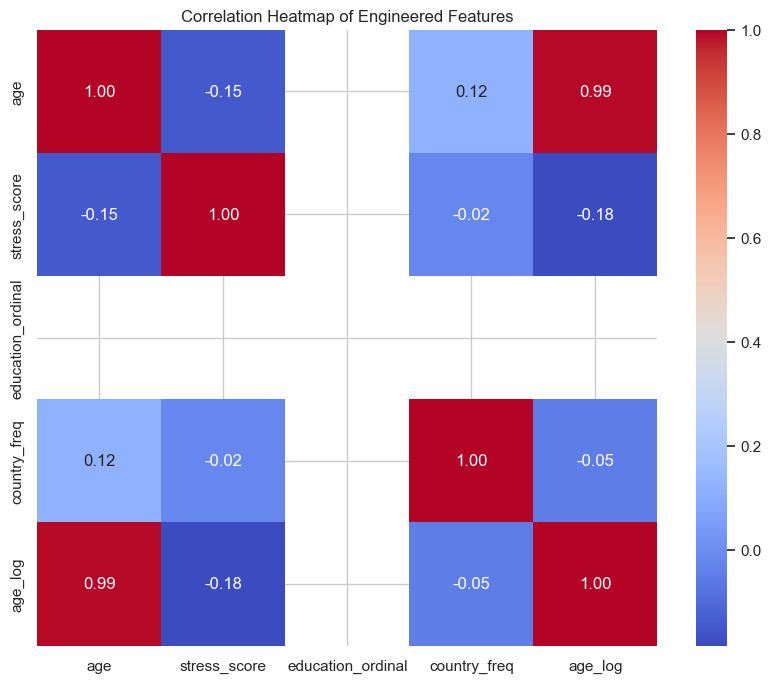

In [89]:
features_to_check = ['age', 'stress_score', 'education_ordinal', 'country_freq', 'age_log']
corr_matrix = df[features_to_check].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Engineered Features')
plt.show()

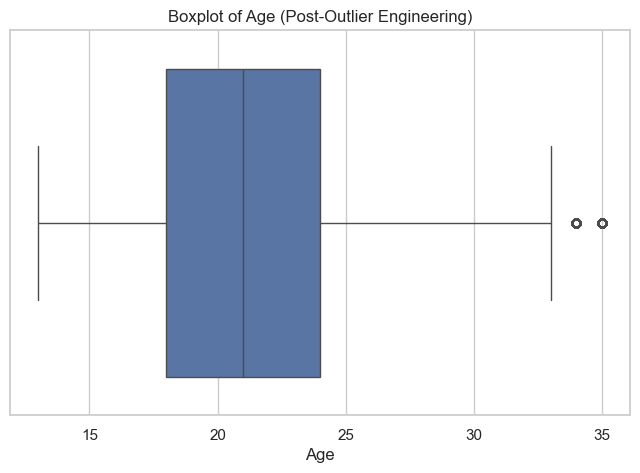

In [90]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age (Post-Outlier Engineering)')
plt.xlabel('Age')
plt.show()

# 2. CREATE A TABLE 

In [91]:
severity_summary = pd.DataFrame({
    'Depression': df['depression_level'].value_counts(),
    'Anxiety': df['anxiety_level'].value_counts(),
    'Stress': df['stress_level'].value_counts()
})

order = ['Normal', 'Mild', 'Moderate', 'Severe', 'Extremely Severe']
severity_summary = severity_summary.reindex(order)

severity_summary

,Depression,Anxiety,Stress
Normal,8856,12492,6252
Mild,3786,5690,4317
Moderate,7079,8598,8567
Severe,6477,6722,8638
Extremely Severe,13577,6273,12001


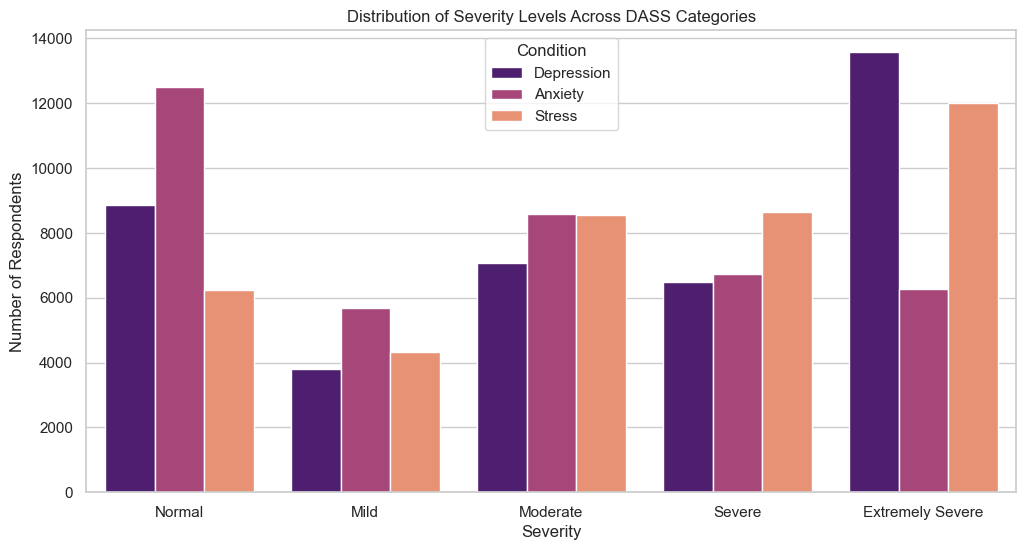

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = severity_summary.reset_index().melt(id_vars='index', var_name='Condition', value_name='Count')
plot_df.columns = ['Severity', 'Condition', 'Count']

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='Severity', y='Count', hue='Condition', palette='magma')
plt.title('Distribution of Severity Levels Across DASS Categories')
plt.ylabel('Number of Respondents')
plt.show()

# 4. Create regression models that predicts depression score, anxiety score and stress scores and measure the model performance using MAE, RMSE and R-Squared

In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [95]:
df_reg = df.copy()

le_gender = LabelEncoder()
le_education = LabelEncoder()
le_country = LabelEncoder()

df_reg['gender_encoded'] = le_gender.fit_transform(df_reg['gender'].fillna('Unknown'))
df_reg['education_encoded'] = le_education.fit_transform(df_reg['education'].fillna('Unknown'))
df_reg['country_encoded'] = le_country.fit_transform(df_reg['country'].fillna('Unknown'))

feature_columns = [
    'age', 'gender_encoded', 'education_encoded', 'country_encoded',
    'TIPI1', 'TIPI2', 'TIPI3', 'TIPI4', 'TIPI5', 'TIPI6', 'TIPI7', 'TIPI8', 'TIPI9', 'TIPI10',
    'VCL1', 'VCL2', 'VCL3', 'VCL4', 'VCL5', 'VCL6', 'VCL7', 'VCL8', 'VCL9', 'VCL10', 
    'VCL11', 'VCL12', 'VCL13', 'VCL14', 'VCL15', 'VCL16'
]


df_reg_clean = df_reg.dropna(subset=feature_columns + ['depression_score', 'anxiety_score', 'stress_score'])


X = df_reg_clean[feature_columns]
targets_reg = ['depression_score', 'anxiety_score', 'stress_score']


results_reg = []

for target in targets_reg:
    y = df_reg_clean[target]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
    }
    
    for model_name, model in models.items():
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        results_reg.append({
            'Target': target,
            'Model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'R-Squared': r2
        })

reg_results_df = pd.DataFrame(results_reg)
print("Regression Model Performance:")
print(reg_results_df.to_string(index=False))

best_models = reg_results_df.loc[reg_results_df.groupby('Target')['R-Squared'].idxmax()]
print("\nBest Models for Each Target:")
print(best_models[['Target', 'Model', 'R-Squared']].to_string(index=False))

Regression Model Performance:
          Target             Model      MAE     RMSE  R-Squared
depression_score Linear Regression 8.085582 9.891142   0.343507
depression_score     Random Forest 7.987695 9.819561   0.352974
   anxiety_score Linear Regression 6.694774 8.329128   0.337548
   anxiety_score     Random Forest 6.577185 8.181508   0.360822
    stress_score Linear Regression 6.212441 7.764451   0.446090
    stress_score     Random Forest 6.001974 7.558158   0.475132

Best Models for Each Target:
          Target         Model  R-Squared
   anxiety_score Random Forest   0.360822
depression_score Random Forest   0.352974
    stress_score Random Forest   0.475132
